In [2]:
import geopandas as gpd
import pandas as pd

Load shapefile and cleaned Covid19 data

In [9]:
gdf = gpd.read_file('india_states.geojson')
merged = pd.read_csv('covid_with_ratios.csv', parse_dates=['Date'])
print(merged['State'].nunique())

print("Shapefile CRS:", gdf.crs)
print("Shapefile shape:", gdf.shape)
print("Shapefile state names:", sorted(gdf['NAME_1'].unique()))

36
Shapefile CRS: EPSG:4326
Shapefile shape: (35, 10)
Shapefile state names: ['Andaman and Nicobar', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Orissa', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Tripura', 'Uttar Pradesh', 'Uttaranchal', 'West Bengal']


Check names mismatches between shapefile and our dataset

In [10]:
shapefile_states = set(gdf['NAME_1'].unique())
our_states = set(merged['State'].unique())

print("In our data but not in shapefile:", our_states - shapefile_states)
print("In shapefile but not in our data:", shapefile_states - our_states)

In our data but not in shapefile: {'Dadra and Nagar Haveli and Daman and Diu', 'Telangana', 'Odisha', 'Uttarakhand', 'Ladakh', 'Andaman and Nicobar Islands'}
In shapefile but not in our data: {'Daman and Diu', 'Dadra and Nagar Haveli', 'Andaman and Nicobar', 'Uttaranchal', 'Orissa'}


1. Simple renames

In [11]:
rename_map = {
    'Orissa': 'Odisha',
    'Uttaranchal': 'Uttarakhand',
    'Andaman and Nicobar': 'Andaman and Nicobar Islands',
}
gdf['NAME_1'] = gdf['NAME_1'].replace(rename_map)

2. Dissolve Dadra and Nagar Havelo + Daman & Diu into one polygon

In [12]:
dnh_dd = gdf[gdf['NAME_1'].isin(['Dadra and Nagar Haveli', 'Daman and Diu'])].copy()
dnh_dd['NAME_1'] = 'Dadra and Nagar Haveli and Daman and Diu'
dnh_dd_dissolved = dnh_dd.dissolve(by='NAME_1').reset_index()

gdf = gdf[~gdf['NAME_1'].isin(['Dadra and Nagar Haveli', 'Daman and Diu'])]
gdf = pd.concat([gdf, dnh_dd_dissolved[['NAME_1', 'geometry']]], ignore_index=True)

print(f"Shapefile now has {gdf['NAME_1'].nunique()} unique state names")

Shapefile now has 34 unique state names


3. Find out if Andra Pradesh and JK listed are before AP-Telagana and JK-Ladakh split or after

In [13]:
gdf_metric = gdf.to_crs('EPSG:24378')

ap_area_km2 = gdf_metric[gdf_metric['NAME_1']=='Andhra Pradesh'].geometry.area.sum() / 1e6
jk_area_km2 = gdf_metric[gdf_metric['NAME_1']=='Jammu and Kashmir'].geometry.area.sum() / 1e6

print(f"Shapefile Andhra Pradesh area: {ap_area_km2:,.0f} km²")
print("  (Real current AP alone: ~162,970 km² | Real AP+Telangana combined: ~275,045 km²)")
print(f"Shapefile Jammu and Kashmir area: {jk_area_km2:,.0f} km²")
print("  (Real current J&K alone: ~42,241 km² | Real J&K+Ladakh combined: ~101,387 km²)")

Shapefile Andhra Pradesh area: 295,391 km²
  (Real current AP alone: ~162,970 km² | Real AP+Telangana combined: ~275,045 km²)
Shapefile Jammu and Kashmir area: 105,470 km²
  (Real current J&K alone: ~42,241 km² | Real J&K+Ladakh combined: ~101,387 km²)


4. Aggregate out covid data to match pre-split boundaries

In [14]:
merge_to_old_boundary = {
    'Telangana': 'Andhra Pradesh',
    'Ladakh': 'Jammu and Kashmir',
}
merged['State_Mapped'] = merged['State'].replace(merge_to_old_boundary)

print(f"Our data now has {merged['State_Mapped'].nunique()} unique states after boundary aggregation")

Our data now has 34 unique states after boundary aggregation


5. Final check

In [15]:
shapefile_states = set(gdf['NAME_1'].unique())
our_states = set(merged['State_Mapped'].unique())

print("Remaining mismatch (our data not in shapefile):", our_states - shapefile_states)
print("Remaining mismatch (shapefile not in our data):", shapefile_states - our_states)

gdf.to_file('india_states_cleaned.geojson', driver='GeoJSON')
merged.to_csv('covid_with_mapped_states.csv', index=False)

Remaining mismatch (our data not in shapefile): set()
Remaining mismatch (shapefile not in our data): set()


#### Chloropeth 1: Peak test positivity rate by State

In [16]:
import matplotlib.pyplot as plt

# Compute peak positivity rate per state
peak_positivity = merged.groupby('State_Mapped')['Positivity_Rate'].max().reset_index()
peak_positivity.columns = ['NAME_1', 'Peak_Positivity_Rate']  # rename to match shapefile's join key

print(f"States with peak positivity data: {peak_positivity['Peak_Positivity_Rate'].notna().sum()} out of {len(peak_positivity)}")
print(peak_positivity.sort_values('Peak_Positivity_Rate', ascending=False).head(10))

States with peak positivity data: 33 out of 34
                         NAME_1  Peak_Positivity_Rate
1                Andhra Pradesh              0.219857
19                  Maharashtra              0.207251
25                   Puducherry              0.188478
8                         Delhi              0.168443
5                    Chandigarh              0.145161
29                   Tamil Nadu              0.130066
15                    Karnataka              0.114300
18               Madhya Pradesh              0.097749
16                       Kerala              0.096552
0   Andaman and Nicobar Islands              0.095173


In [17]:
# Merge onto geometry
gdf_merged = gdf.merge(peak_positivity, on='NAME_1', how='left')

# Check for any states in the shapefile that got no data after merge
missing_data = gdf_merged[gdf_merged['Peak_Positivity_Rate'].isna()]['NAME_1'].tolist()
print(f"States with NO positivity data after merge (will render blank): {missing_data}")

States with NO positivity data after merge (will render blank): ['Lakshadweep']


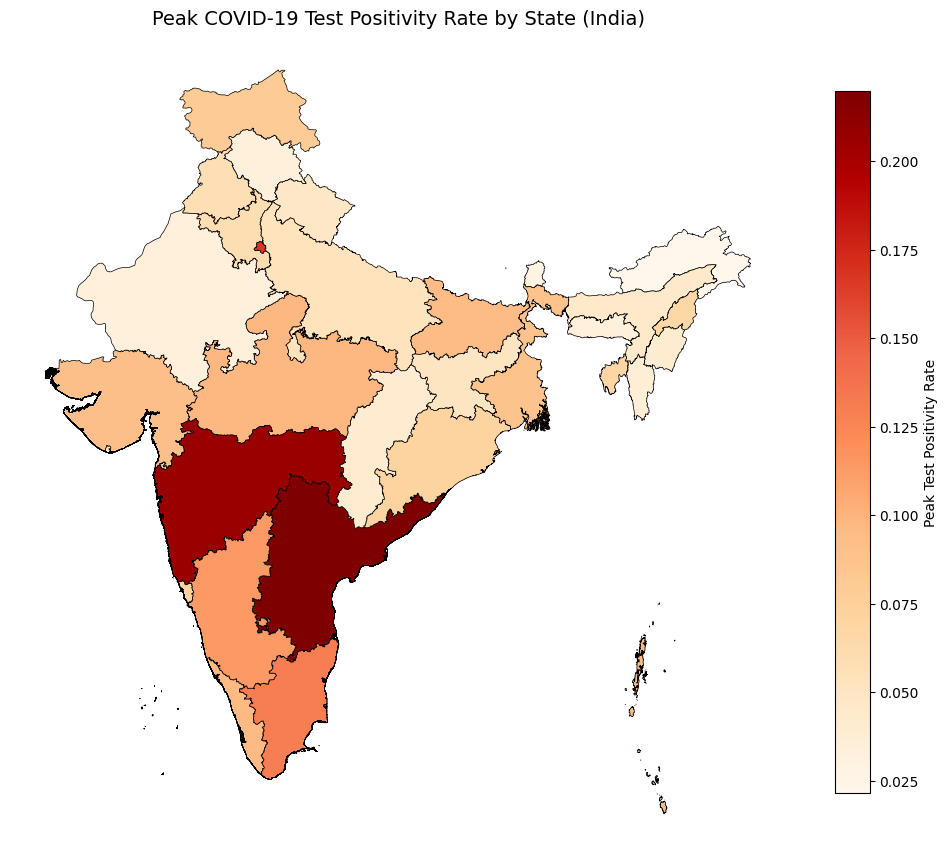

In [18]:
# Plot chloropeth
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

gdf_merged.plot(
    column='Peak_Positivity_Rate',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Peak Test Positivity Rate', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    ax=ax
)
ax.set_title('Peak COVID-19 Test Positivity Rate by State (India)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('choropleth_peak_positivity.png', dpi=120)
plt.show()

Choropleth 1: Peak Test Positivity Rate by State


**Result**: 33 of 34 states rendered with data; Lakshadweep has no positivity
data in the source dataset. Maharashtra (20.7%) and Andhra Pradesh (22.0%, includes
aggregated Telangana data) show the
highest peak positivity, consistent with widely reported accounts of these
states being among the hardest-hit during the pandemic, particularly the
2021 Delta wave. Note: Andhra Pradesh's figure reflects the combined
AP+Telangana region due to the shapefile boundary limitation

In [19]:
merged_sorted = merged.sort_values('Date')

latest_per_real_state = merged_sorted.groupby('State').last().reset_index()
latest_per_real_state['State_Mapped'] = latest_per_real_state['State'].replace({
    'Telangana': 'Andhra Pradesh', 'Ladakh': 'Jammu and Kashmir'
})
state_totals = latest_per_real_state.groupby('State_Mapped').agg(
    Total_Confirmed=('Confirmed', 'sum'),
    Total_Deaths=('Deaths', 'sum'),
    Total_Vaccinated=('Total Individuals Vaccinated', 'sum')
).reset_index()

# CFR
state_totals['CFR'] = state_totals['Total_Deaths'] / state_totals['Total_Confirmed']

In [20]:
state_population_millions = {
    'Uttar Pradesh': 231.5, 'Maharashtra': 123.1, 'Bihar': 124.8, 'West Bengal': 99.6,
    'Madhya Pradesh': 85.0, 'Tamil Nadu': 77.8, 'Rajasthan': 81.0, 'Karnataka': 67.6,
    'Gujarat': 70.4, 'Andhra Pradesh': 93.3, 'Odisha': 46.4, 'Jharkhand': 38.6,
    'Assam': 34.3, 'Punjab': 30.5, 'Chhattisgarh': 29.4, 'Haryana': 28.9,
    'Delhi': 19.8, 'Jammu and Kashmir': 26.4, 'Uttarakhand': 11.4,
    'Himachal Pradesh': 7.3, 'Tripura': 4.2, 'Meghalaya': 3.4, 'Manipur': 3.3,
    'Nagaland': 2.2, 'Goa': 1.6, 'Arunachal Pradesh': 1.6, 'Puducherry': 1.6,
    'Mizoram': 1.2, 'Chandigarh': 1.2, 'Sikkim': 0.7, 'Kerala': 35.7,
    'Andaman and Nicobar Islands': 0.4, 'Lakshadweep': 0.07,
    'Dadra and Nagar Haveli and Daman and Diu': 0.6,
}
state_totals['Population_Millions'] = state_totals['State_Mapped'].map(state_population_millions)

missing_pop = state_totals[state_totals['Population_Millions'].isna()]['State_Mapped'].tolist()
print(f"States with NO population match: {missing_pop}")
assert len(missing_pop) == 0, "Fix the population dict before continuing!"

state_totals['Vaccination_Rate'] = state_totals['Total_Vaccinated'] / (state_totals['Population_Millions'] * 1_000_000)
state_totals.to_csv('state_totals_for_maps.csv', index=False)
print(state_totals.sort_values('Total_Confirmed', ascending=False).head(10))

States with NO population match: []
      State_Mapped  Total_Confirmed  Total_Deaths  Total_Vaccinated       CFR  \
19     Maharashtra          6363442        134201        24046509.0  0.021089   
16          Kerala          3586693         18004        10258975.0  0.005020   
15       Karnataka          2921049         36848        17493598.0  0.012615   
1   Andhra Pradesh          2635535         17395        20016303.0  0.006600   
29      Tamil Nadu          2579130         34367        11658908.0  0.013325   
31   Uttar Pradesh          1708812         22775        24782239.0  0.013328   
33     West Bengal          1534999         18252        15798841.0  0.011891   
8            Delhi          1436852         25068         5318124.0  0.017446   
6     Chhattisgarh          1003356         13544         5739810.0  0.013499   
24          Odisha           988997          6565         9126091.0  0.006638   

    Population_Millions  Vaccination_Rate  
19                123.1     

In [21]:
gdf_merged = gdf.merge(state_totals, left_on='NAME_1', right_on='State_Mapped', how='left')

#### Chloropeth 2: Total confirmed cases by state

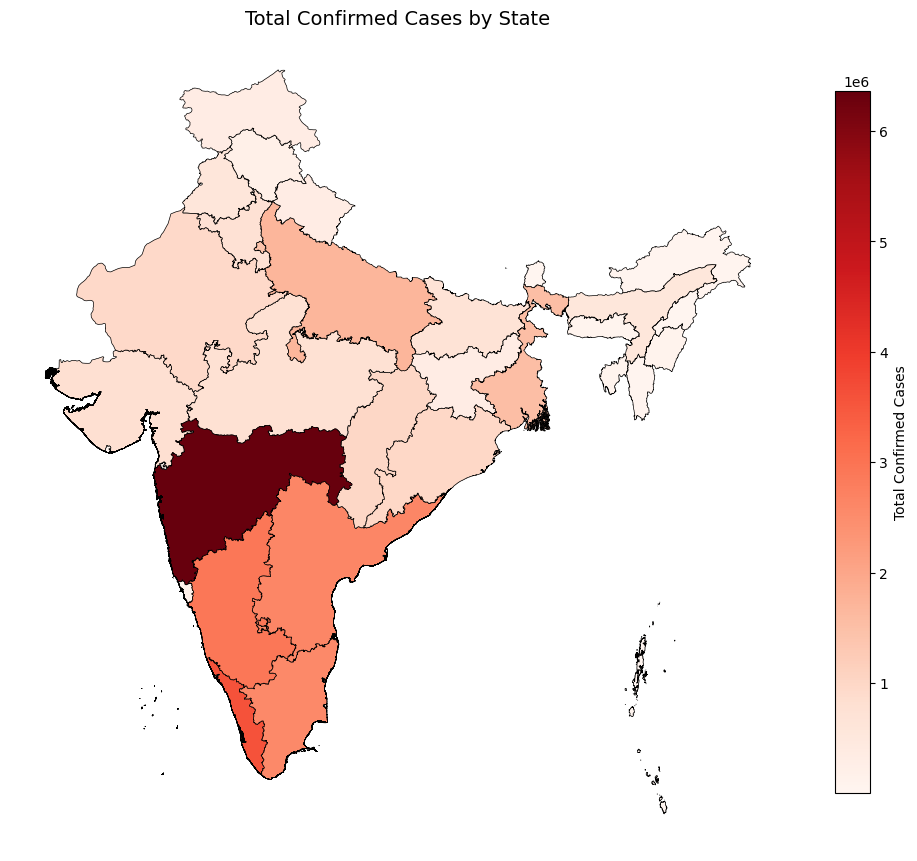

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
gdf_merged.plot(
    column='Total_Confirmed', cmap='Reds', linewidth=0.5, edgecolor='black',
    legend=True, legend_kwds={'label': 'Total Confirmed Cases', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}, ax=ax
)
ax.set_title('Total Confirmed Cases by State', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('choropleth_total_confirmed.png', dpi=120)
plt.show()

Chloropeth 2: Total confirmed cases by state

Result: Maharastra dominant (~6.35M), consistent with the 1st map and widely reported case burden data.

#### Chloropeth 3: Case Fatality Rate by State

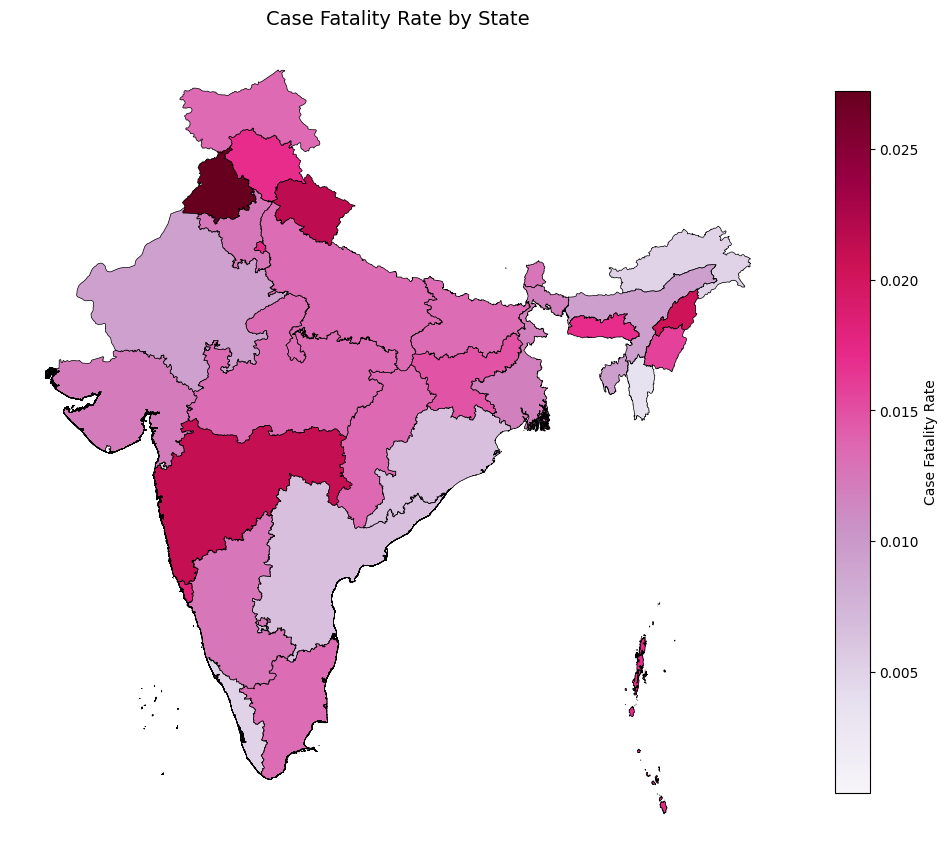

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
gdf_merged.plot(
    column='CFR', cmap='PuRd', linewidth=0.5, edgecolor='black',
    legend=True, legend_kwds={'label': 'Case Fatality Rate', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}, ax=ax
)
ax.set_title('Case Fatality Rate by State', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('choropleth_cfr.png', dpi=120)
plt.show()

Chloropeth 3: Case Fatality Rate by State

Result: Though Maharastra had the most number of confirmed cases, Punjab has the highest CFR (2.72%).

#### Chloropeth 4: Vaccination coverage rate by state

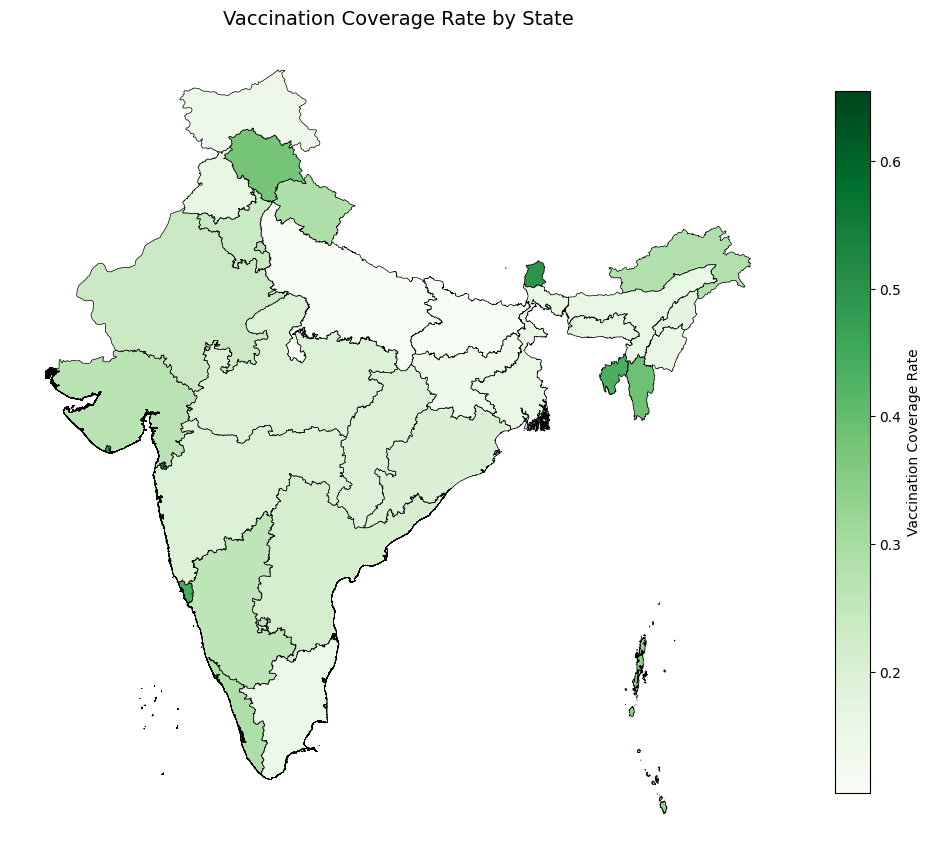

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
gdf_merged.plot(
    column='Vaccination_Rate', cmap='Greens', linewidth=0.5, edgecolor='black',
    legend=True, legend_kwds={'label': 'Vaccination Coverage Rate', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}, ax=ax
)
ax.set_title('Vaccination Coverage Rate by State', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('choropleth_vaccination_rate.png', dpi=120)
plt.show()

Chloropeth 4: Vaccination Coverage rate

Result:
Dominated by small-population UTs — Lakshadweep
(~65%), Dadra and Nagar Haveli and Daman and Diu (~52%), Sikkim (~50%). This
is a real, well-documented pattern (smaller populations reach high per-capita
coverage faster with less logistical complexity)